The notebooks includes the process of feature selection

In [1]:
import os
import matplotlib.pyplot as plt
import geopandas
import pandas as pd
import seaborn as sn
import numpy as np
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

Setting the directory

In [2]:
os.chdir('C:/Flood Data/Flood Extract Point')

Reading the .csv file with predictor variables and target variable

In [3]:
data=pd.read_csv('Flood_extractvalues_New_duplicate.csv')
data_cleaned = data.dropna()
#data_cleaned = data.drop(columns=['Dist_River','Solar_Radiation_Final'])
data_cleaned.head()

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_RX3day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,Class
0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,127.795547,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717,0
1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,128.454819,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682,0
2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,139.315689,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078,0
3,338.198578,1899.0,37.013485,-0.640000,0.640000,80.411331,137.253937,1597.987915,0.204164,17.0,5.807874,2.808194,2.0,16.0,-0.768516,372.050568,0.403678,0
4,354.093872,4167.0,49.387146,-0.680899,-0.040899,96.287956,164.629257,1899.889404,0.012031,20.0,3.683581,3.470599,1.0,14.0,0.049714,1663.860718,0.276737,0


Plotting the correlation matrix to check the linear relation between our predictors

In [4]:
df = data_cleaned.iloc[:, :-1]
#dropping categorical variables
df= df.drop(columns=['LULC','Soil','Geology'])
#generating correlation matrix
corr = df.corr(method='pearson')

In [5]:
from scipy.stats import pearsonr

cols = df.columns
pvals = pd.DataFrame(np.ones((len(cols), len(cols))), columns=cols, index=cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        r, p = pearsonr(df.iloc[:, i], df.iloc[:, j])
        pvals.iloc[i, j] = p


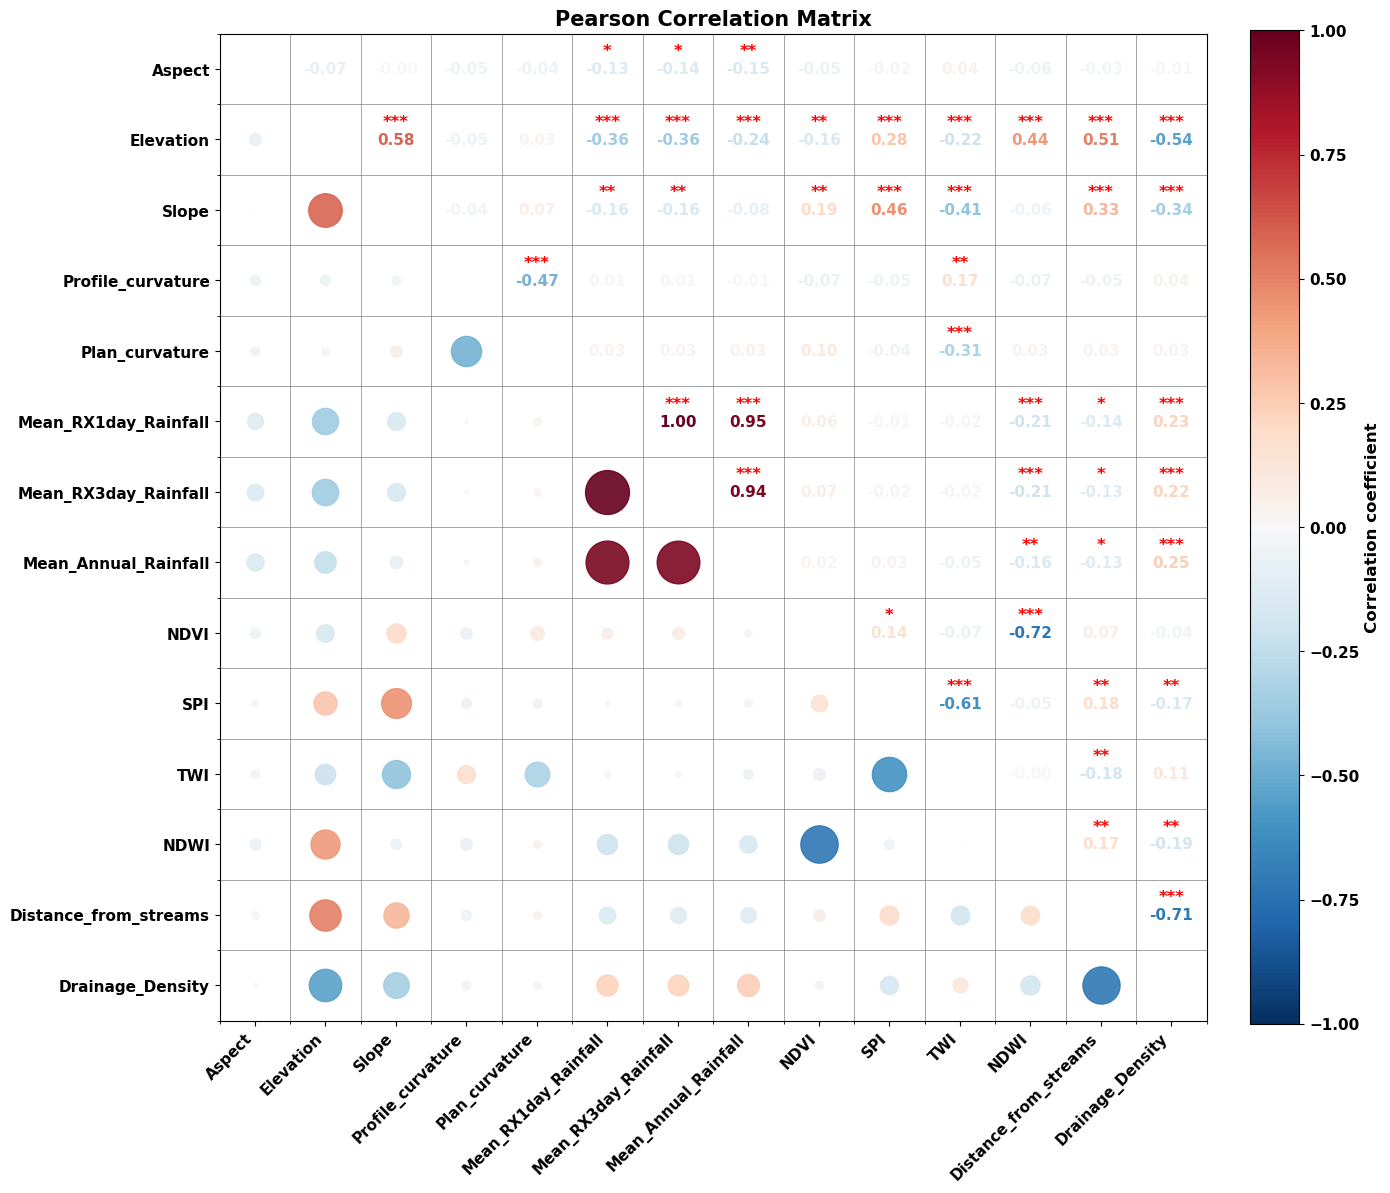

In [28]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(14, 14))

cmap = mpl.cm.RdBu_r
norm = mpl.colors.Normalize(vmin=-1, vmax=1)

n = len(corr)

for i in range(n):
    for j in range(n):

        r = corr.iloc[i, j]

        # LOWER TRIANGLE → CIRCLES
        if i > j:
            size = abs(r) * 1000
            ax.scatter(j + 0.5, i + 0.5,
                       s=size,
                       color=cmap(norm(r)),
                       alpha=0.9)

        # UPPER TRIANGLE → NUMBERS + SIGNIFICANCE
        elif i < j:

            # significance stars
            if pvals.iloc[i, j] < 0.001:
                star = "***"
            elif pvals.iloc[i, j] < 0.01:
                star = "**"
            elif pvals.iloc[i, j] < 0.05:
                star = "*"
            else:
                star = ""

            # correlation value
            ax.text(j + 0.5, i + 0.5,
                    f"{r:.2f}",
                    ha='center',
                    va='center',
                    fontsize=11,
                    fontweight='bold',
                    color=cmap(norm(r)))

            # stars (slightly above)
            if star:
                ax.text(j + 0.5, i + 0.25,
                        star,
                        ha='center',
                        va='center',
                        color='red',
                        fontsize=12,
                        fontweight='bold')

# ---------------------------
# Axis formatting
# --- Center ticks inside boxes ---
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)

ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=11,fontweight='bold')
ax.set_yticklabels(corr.columns, fontsize=11,fontweight='bold')

# --- Set proper limits ---
ax.set_xlim(0, n)
ax.set_ylim(n, 0)

# --- Draw grid lines manually at box borders ---
ax.set_xticks(np.arange(n+1), minor=True)
ax.set_yticks(np.arange(n+1), minor=True)

ax.grid(which='minor', color='grey', linestyle='-', linewidth=0.5)
ax.grid(False)  # remove major grid

# --- Make cells perfectly square ---
ax.set_aspect('equal')

# Colorbar
# ---------------------------
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation coefficient", fontsize=12,fontweight='bold')
# 🔥 Make colorbar tick labels bold
cbar.ax.tick_params(labelsize=11)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.title("Pearson Correlation Matrix", fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig("C:/Flood Data/Flood Figures/Correlation_bubble_Pearson.png", dpi=600, bbox_inches='tight')
plt.show()


We can see, that there are several variables that are highly correlated, especially the climate data. Let's remove some of them

In [12]:
# The below code shows all columns that are more correlated that a given threshold
# It's just selecting from the correlation matrix. 
def test_correlation(df, cutoff=0.80):
    abs_corr = df.corr().abs()
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > cutoff)]
    return to_drop

# Print the columns to drop
test_correlation(df)

['Mean_RX3day_Rainfall', 'Mean_Annual_Rainfall']

Drop highly correlated predictors


In [13]:
data_selected = data.drop(columns=['Mean_RX3day_Rainfall'])

Showing the first 5 rows of the data to see that the columns are removed

In [14]:
data_selected.head()

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,Class
0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717,0
1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682,0
2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078,0
3,338.198578,1899.0,37.013485,-0.640000,0.640000,80.411331,1597.987915,0.204164,17.0,5.807874,2.808194,2.0,16.0,-0.768516,372.050568,0.403678,0
4,354.093872,4167.0,49.387146,-0.680899,-0.040899,96.287956,1899.889404,0.012031,20.0,3.683581,3.470599,1.0,14.0,0.049714,1663.860718,0.276737,0


Plotting a new correlation matrix without highly correlated features

Aspect: MI = 0.0107
Elevation: MI = 0.2797
Slope: MI = 0.3742
Profile_curvature: MI = 0.0168
Plan_curvature: MI = 0.0275
Mean_RX1day_Rainfall: MI = 0.0690
Mean_Annual_Rainfall: MI = 0.0649
NDVI: MI = 0.0626
LULC: MI = 0.0277
SPI: MI = 0.0816
TWI: MI = 0.0964
Soil: MI = 0.2201
Geology: MI = 0.1103
NDWI: MI = 0.1960
Distance_from_streams: MI = 0.0880
Drainage_Density: MI = 0.1264
                  Feature  MINE_Score  MINE_Score_Norm
2                   Slope    0.374190         1.000000
1               Elevation    0.279734         0.740159
11                   Soil    0.220148         0.576241
13                   NDWI    0.196041         0.509925
15       Drainage_Density    0.126384         0.318303
12                Geology    0.110310         0.274085
10                    TWI    0.096422         0.235880
14  Distance_from_streams    0.088041         0.212824
9                     SPI    0.081578         0.195044
5    Mean_RX1day_Rainfall    0.068987         0.160409
6    Mean_Annu

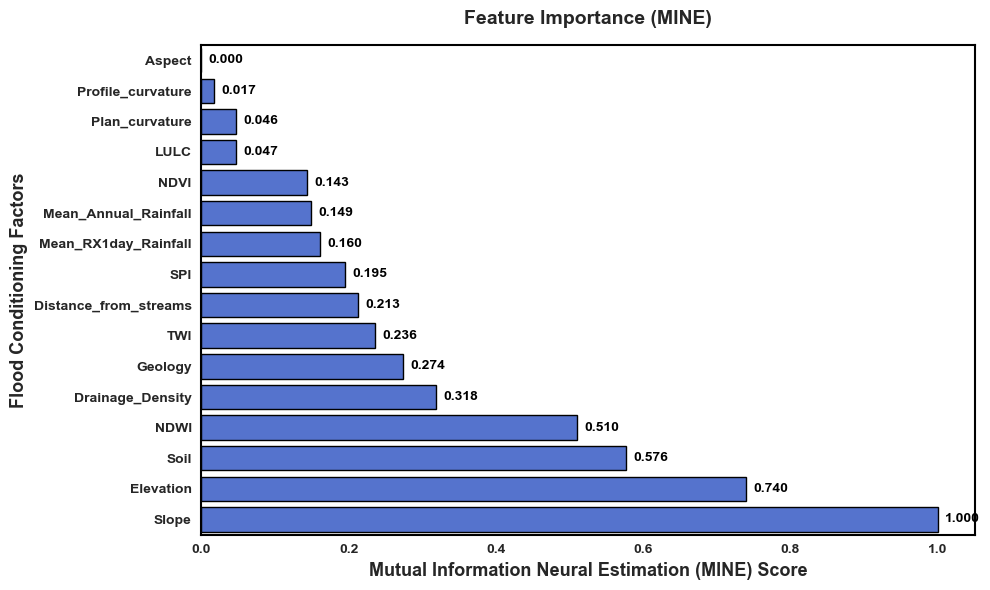

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# 1. Prepare your data
# ----------------------------------------------------
# data_cleaned = pd.read_csv("Flood_extractvalues_New.csv").dropna()

X = data_cleaned.iloc[:, :-1]
y = data_cleaned.iloc[:, -1].astype(float)
# Drop the correlated feature
if 'Mean_RX3day_Rainfall' in X.columns:
    X = X.drop(columns=['Mean_RX3day_Rainfall'])

cat_cols = ['LULC', 'Soil', 'Geology']

# Encode categorical columns
X_enc = X.copy()
for col in cat_cols:
    if col in X_enc.columns:
        le = LabelEncoder()
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))

# Scale features 0–1
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_enc), columns=X_enc.columns)

# Convert target to tensor
y_tensor = torch.tensor(y.values).float().view(-1, 1)

# ----------------------------------------------------
# 2. Define the MINE neural network
# ----------------------------------------------------
class MINE(nn.Module):
    def __init__(self, x_dim):
        super(MINE, self).__init__()
        self.fc1 = nn.Linear(x_dim + 1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        h = self.relu(self.fc1(xy))
        h = self.relu(self.fc2(h))
        return self.fc3(h)

# ----------------------------------------------------
# 3. Mutual Information estimation function
# ----------------------------------------------------
def mutual_information(x, y, mine_net, mine_optimizer, steps=200, batch_size=128):
    dataset = torch.cat((x, y), dim=1)
    n_samples = dataset.shape[0]
    for step in range(steps):
        # Random batch sampling
        idx = np.random.choice(n_samples, batch_size, replace=True)
        joint = dataset[idx]
        marg = torch.cat((x[idx], y[torch.randperm(n_samples)[:batch_size]]), dim=1)
        t = mine_net(joint[:, :-1], joint[:, -1:])
        t_marg = mine_net(marg[:, :-1], marg[:, -1:])
        loss = - (torch.mean(t) - torch.log(torch.mean(torch.exp(t_marg))))
        mine_optimizer.zero_grad()
        loss.backward()
        mine_optimizer.step()
    # After training, estimate MI
    joint_t = mine_net(x, y)
    marg_t = mine_net(x, y[torch.randperm(n_samples)])
    mi_est = torch.mean(joint_t) - torch.log(torch.mean(torch.exp(marg_t)))
    return mi_est.item()

# ----------------------------------------------------
# 4. Apply MINE for each feature
# ----------------------------------------------------
mi_scores = []
for feature in X_scaled.columns:
    x_feat = torch.tensor(X_scaled[[feature]].values).float()
    mine_net = MINE(x_dim=1)
    optimizer = optim.Adam(mine_net.parameters(), lr=1e-3)
    mi_value = mutual_information(x_feat, y_tensor, mine_net, optimizer, steps=300)
    mi_scores.append(mi_value)
    print(f"{feature}: MI = {mi_value:.4f}")

# ----------------------------------------------------
# 5. Prepare output DataFrame
# ----------------------------------------------------
mine_results = pd.DataFrame({
    'Feature': X_scaled.columns,
    'MINE_Score': mi_scores
}).sort_values(by='MINE_Score', ascending=False)

# Normalize 0–1
mine_results['MINE_Score_Norm'] = (mine_results['MINE_Score'] - mine_results['MINE_Score'].min()) / (
    mine_results['MINE_Score'].max() - mine_results['MINE_Score'].min()
)

print(mine_results)

# ----------------------------------------------------
# 6. Plot
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial Black'
plt.rcParams['font.weight'] = 'bold'
sns.set_style("white")

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=mine_results.sort_values('MINE_Score_Norm', ascending=True),
    x='MINE_Score_Norm', y='Feature', color='royalblue', edgecolor='black'
)

plt.xlabel("Mutual Information Neural Estimation (MINE) Score", fontsize=13, fontweight='bold')
plt.ylabel("Flood Conditioning Factors", fontsize=13, fontweight='bold')
plt.title("Feature Importance (MINE)", fontsize=14, fontweight='bold', pad=15)

for i, v in enumerate(mine_results.sort_values('MINE_Score_Norm', ascending=True)['MINE_Score_Norm']):
    plt.text(v + 0.01, i, f"{v:.3f}", color='black', va='center', fontsize=10, fontweight='bold')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
#plt.savefig('C:/Flood Data/Flood Figures/MINE_Feature_Importance_Neural.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


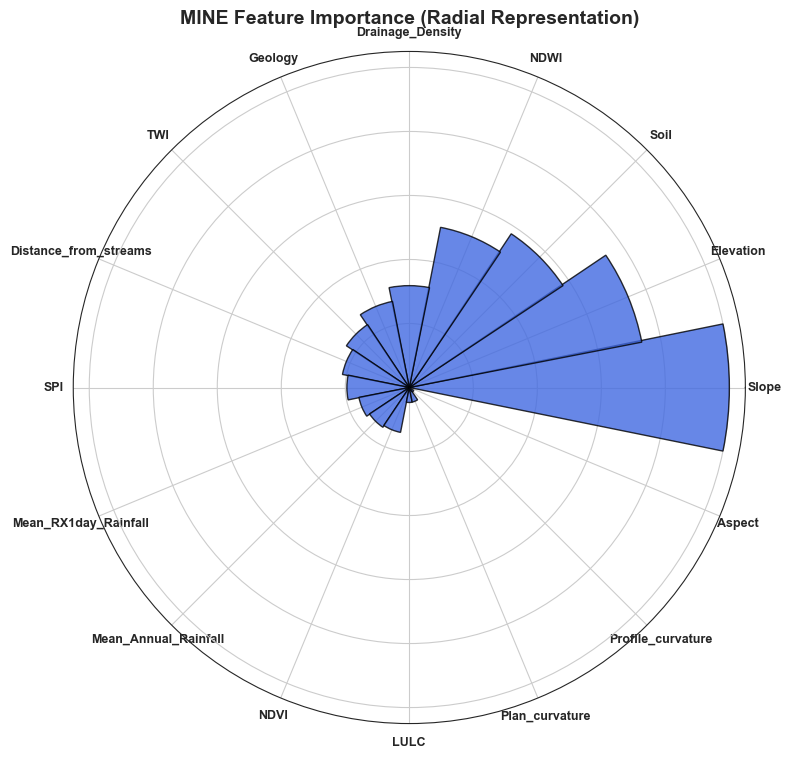

In [16]:
import numpy as np
import matplotlib.pyplot as plt

mine_sorted = mine_results.sort_values('MINE_Score_Norm', ascending=False)
angles = np.linspace(0, 2*np.pi, len(mine_sorted), endpoint=False)
radii = mine_sorted['MINE_Score_Norm']
labels = mine_sorted['Feature']

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)
bars = ax.bar(angles, radii, width=0.4, bottom=0.0, color='royalblue', alpha=0.8, edgecolor='black')

ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
plt.title("MINE Feature Importance (Radial Representation)",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('C:/Flood Data/Flood Figures/MINE_CircularBar.png', dpi=600, bbox_inches='tight')
plt.show()


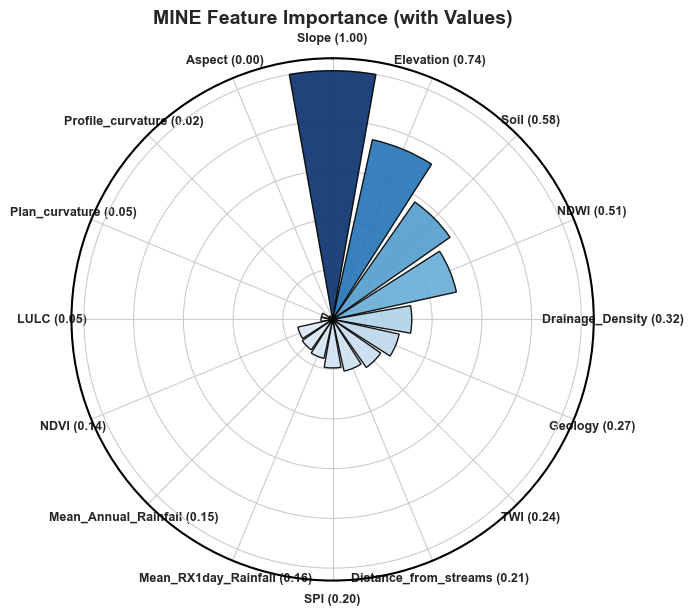

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Sort by normalized MINE scores (descending)
mine_sorted = mine_results.sort_values('MINE_Score_Norm', ascending=False)
angles = np.linspace(0, 2*np.pi, len(mine_sorted), endpoint=False)
radii = mine_sorted['MINE_Score_Norm']
labels = mine_sorted['Feature']

# Create new labels with MINE values in brackets
label_with_values = [
    f"{feat} ({val:.2f})" for feat, val in zip(labels, radii)
]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# Create bars with color gradient (optional)
colors = plt.cm.Blues(radii / max(radii))
bars = ax.bar(
    angles,
    radii,
    width=0.35,
    bottom=0.0,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Set labels (feature name + value)
ax.set_xticks(angles)
ax.set_xticklabels(label_with_values, fontsize=9, fontweight='bold')

# Remove radial labels
ax.set_yticklabels([])

# Optional: start from top (not right)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Add title
plt.title("MINE Feature Importance (with Values)", fontsize=14, fontweight='bold', pad=25)

# Add border for clean finish
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig('C:/Flood Data/Flood Figures/MINE_CircularBar_LabelsWithValues.png',
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


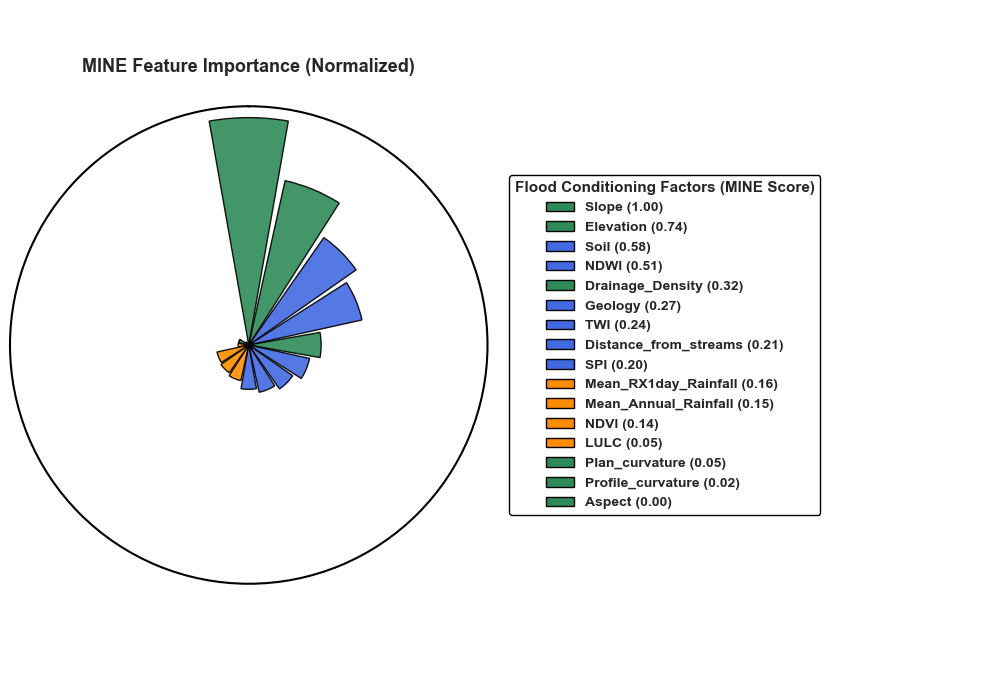

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Sort features by normalized MINE score (descending)
mine_sorted = mine_results.sort_values('MINE_Score_Norm', ascending=False)
angles = np.linspace(0, 2*np.pi, len(mine_sorted), endpoint=False)
radii = mine_sorted['MINE_Score_Norm']
labels = mine_sorted['Feature']

# --- Assign custom color categories ---
# Example grouping: Terrain, Hydrological, Climatic
terrain_vars = ['Slope', 'Elevation', 'Aspect', 'Plan_curvature', 'Profile_curvature', 'Drainage_Density']
hydro_vars = ['Soil', 'TWI', 'SPI', 'NDWI', 'Distance_from_streams', 'Geology']
climate_vars = ['Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC']

colors = []
for f in labels:
    if f in terrain_vars:
        colors.append('seagreen')
    elif f in hydro_vars:
        colors.append('royalblue')
    elif f in climate_vars:
        colors.append('darkorange')
    else:
        colors.append('gray')

# --- Create figure ---
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(121, polar=True)  # left: circular plot
ax2 = plt.subplot(122)             # right: legend panel
ax2.axis('off')                    # hide axis

# --- Polar bars ---
bars = ax.bar(
    angles,
    radii,
    width=0.35,
    bottom=0.0,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# --- Polar setup ---
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_yticklabels([])
ax.grid(False)
ax.set_xticks([])  # no labels around circle

# --- Title ---
ax.set_title("MINE Feature Importance (Normalized)", fontsize=13, fontweight='bold', pad=25)

# --- Legend / label panel ---
legend_elements = []
for f, c, val in zip(labels, colors, radii):
    legend_elements.append(Patch(facecolor=c, edgecolor='black',
                                 label=f"{f} ({val:.2f})"))

# Display the legend as a vertical color-coded list
ax2.legend(
    handles=legend_elements,
    loc='center left',
    fontsize=10,
    frameon=True,
    framealpha=1,
    edgecolor='black',
    title="Flood Conditioning Factors (MINE Score)",
    title_fontsize=11
)

# --- Border around circular plot ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig('C:/Flood Data/Flood Figures/MINE_CircularBar_LegendPanel.png',
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


Saving the final file for machine learning as .csv file

In [58]:
data_selected.to_csv('Flood_data_renew.csv', index = False)